In [6]:
import re
import zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

In [4]:
DATA_DIR = Path("./data")
PROCESSED_DIR = DATA_DIR / "processed"
GLOBAL_DIR = DATA_DIR / "global"
CACHE_DIR = DATA_DIR / "raw/geo"
FIG_DIR = Path("./plots_output")

for folder in [PROCESSED_DIR, GLOBAL_DIR, CACHE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MAPPING_DIR = DATA_DIR / "all_region_to_country"
GADM1_CSV = DATA_DIR / "gadm1/gadm1.csv"
NUTS3_CSV = DATA_DIR / "nuts_2024/nuts3_2024.csv"

def iso2_to_iso3(iso2):
    try:
        import pycountry
        country = pycountry.countries.get(alpha_2=str(iso2).strip().upper())
        return country.alpha_3 if country else None
    except:
        return None

def iso2_to_name(iso2):
    try:
        import pycountry
        country = pycountry.countries.get(alpha_2=str(iso2).strip().upper())
        return country.name if country else None
    except:
        return None

def extract_countries_and_regions_from_mapping(csv_path):
    if not csv_path.exists(): return {}
    iso2_to_regions = defaultdict(set)
    cols = ["user_country", "friend_country", "user_region", "friend_region"]
    df = pd.read_csv(csv_path, dtype=str, usecols=cols)
    within = df["user_country"].str.upper() == df["friend_country"].str.upper()
    for iso2, region in zip(df.loc[within, "user_country"].str.upper(), df.loc[within, "user_region"]):
        iso2_to_regions[iso2].add(str(region))
    for iso2, region in zip(df.loc[within, "friend_country"].str.upper(), df.loc[within, "friend_region"]):
        iso2_to_regions[iso2].add(str(region))
    return dict(iso2_to_regions)

def _download(url, outpath):
    outpath.parent.mkdir(parents=True, exist_ok=True)
    if outpath.exists() and outpath.stat().st_size > 0: return
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        tmp = outpath.with_suffix(outpath.suffix + ".tmp")
        with tmp.open("wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk: f.write(chunk)
        tmp.replace(outpath)

def _representative_points(gdf):
    try:
        if gdf.crs is not None and str(gdf.crs).lower() != "epsg:4326":
            gdf = gdf.to_crs(4326)
    except: pass
    pts = gdf.geometry.representative_point()
    return pts.y.astype(float), pts.x.astype(float)

def _download_and_extract_gadm1(iso3, cache_dir):
    iso3 = iso3.strip().upper()
    if not iso3 or not re.fullmatch(r"[A-Z]{3}", iso3): return None
    zip_url = f"https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_{iso3}_shp.zip"
    zip_path = cache_dir / "gadm41_shp" / f"gadm41_{iso3}_shp.zip"
    try:
        _download(zip_url, zip_path)
    except Exception as e:
        return None
    extract_dir = cache_dir / "gadm41_shp" / f"gadm41_{iso3}"
    if not extract_dir.exists() or not any(extract_dir.glob("*.shp")):
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)
    shp = extract_dir / f"gadm41_{iso3}_1.shp"
    return shp if shp.exists() else None

def build_country_list_and_centroids_pipeline(workers=4):
    gadm1_map_csv = MAPPING_DIR / "gadm1_to_country.csv"
    nuts3_map_csv = MAPPING_DIR / "nuts3_2024_to_country.csv"
    
    if not gadm1_map_csv.exists() or not nuts3_map_csv.exists():
        raise FileNotFoundError(f"Missing mapping files in: {MAPPING_DIR}")
    
    print("Extracting countries and calculating target nodes...")
    iso2_gadm1 = extract_countries_and_regions_from_mapping(gadm1_map_csv)
    iso2_nuts3 = extract_countries_and_regions_from_mapping(nuts3_map_csv)
    
    all_iso2 = (set(iso2_gadm1.keys()) | set(iso2_nuts3.keys())) - {"US"}
    rows = []
    for iso2 in sorted(all_iso2):
        if not iso2 or iso2 in {"", "NAN"}: continue
        iso3 = iso2_to_iso3(iso2) or (iso2 + iso2[0])
        name = iso2_to_name(iso2) or iso2
        n_gadm = len(iso2_gadm1.get(iso2, set()))
        n_nuts = len(iso2_nuts3.get(iso2, set()))
        max_nodes = max(n_gadm, n_nuts)
        
        rows.append({
            "country_ISO2": iso2,
            "country_ISO3": iso3,
            "country_name": name,
            "n_regions_gadm1": n_gadm,
            "n_regions_nuts3": n_nuts,
            "max_nodes": max_nodes
        })
    
    df_countries = pd.DataFrame(rows).sort_values("max_nodes", ascending=False).head(100).reset_index(drop=True)
    df_countries.to_csv(PROCESSED_DIR / "country_list.csv", index=False)
    
    gadm_iso3_targets = df_countries[df_countries["n_regions_nuts3"] == 0]["country_ISO3"].unique().tolist()
    
    print(f"Downloading {len(gadm_iso3_targets)} non-European shapefiles from GADM...")
    parts = []
    rows_centroids = []
    
    with ThreadPoolExecutor(max_workers=workers) as exec:
        futures = {exec.submit(_download_and_extract_gadm1, iso3, CACHE_DIR): iso3 for iso3 in gadm_iso3_targets}
        for f in as_completed(futures):
            shp = f.result()
            if shp:
                gdf = gpd.read_file(shp, engine="fiona")
                if "GID_1" not in gdf.columns: continue
                lat, lon = _representative_points(gdf)
                label_col = "NAME_1" if "NAME_1" in gdf.columns else "GID_1"
                for c, la, lo, lb in zip(gdf["GID_1"], lat, lon, gdf[label_col]):
                    rows_centroids.append({"region_code": str(c), "latitude": float(la), "longitude": float(lo), "nodeLabel": str(lb)})
                    
    if rows_centroids: 
        parts.append(pd.DataFrame(rows_centroids))

    print("Downloading European NUTS GeoJSON from Eurostat...")
    nuts_url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_01M_2024_4326_LEVL_3.geojson"
    geojson_path = CACHE_DIR / "nuts/NUTS_RG_01M_2024_4326_LEVL_3.geojson"
    try:
        _download(nuts_url, geojson_path)
        gdf_nuts = gpd.read_file(geojson_path, engine="fiona")
        lat, lon = _representative_points(gdf_nuts)
        label_col = "NAME_LATN" if "NAME_LATN" in gdf_nuts.columns else "NUTS_ID"
        df_nuts = pd.DataFrame({
            "region_code": gdf_nuts["NUTS_ID"].astype(str),
            "latitude": lat.astype(float),
            "longitude": lon.astype(float),
            "nodeLabel": gdf_nuts[label_col].astype(str)
        })
        parts.append(df_nuts)
    except Exception as e:
        print(f"Failed to load Eurostat file: {e}")
        
    if parts:
        centroids = pd.concat(parts, ignore_index=True).dropna(subset=["region_code"])
        centroids = centroids.drop_duplicates("region_code").reset_index(drop=True)
        centroids.to_csv(PROCESSED_DIR / "centroids.csv", index=False)
        print("Global centroid mapping successfully built!")

build_country_list_and_centroids_pipeline()

def _available_within_countries(layer_csv, chunksize=500000):
    available = set()
    if not Path(layer_csv).exists(): return available
    for chunk in pd.read_csv(layer_csv, chunksize=chunksize, dtype=str, usecols=["user_country", "friend_country"]):
        within = chunk["user_country"].str.upper() == chunk["friend_country"].str.upper()
        if within.any():
            available.update(chunk.loc[within, "user_country"].str.upper().unique().tolist())
    return available

def build_global_network_flow(chunksize=500000):
    centroids_path = PROCESSED_DIR / "centroids.csv"
    country_list_path = PROCESSED_DIR / "country_list.csv"
    
    if not (NUTS3_CSV.exists() and GADM1_CSV.exists() and country_list_path.exists()):
        print("Error: Missing flux files.")
        return
        
    selected = pd.read_csv(country_list_path)
    selected_iso2 = set(selected["country_ISO2"].str.upper().tolist()) - {"US"}
    iso2_to_iso3 = dict(zip(selected["country_ISO2"], selected["country_ISO3"]))
    iso2_to_name = dict(zip(selected["country_ISO2"], selected["country_name"]))
    
    centroids_df = pd.read_csv(centroids_path).set_index("region_code") if centroids_path.exists() else None
    nuts_available = _available_within_countries(NUTS3_CSV, chunksize)
    
    nuts_set = selected_iso2 & nuts_available
    gadm_set = selected_iso2 - nuts_set
    
    node_id_by_key = {}
    node_rows = []
    weights_by_country = defaultdict(lambda: defaultdict(float))
    
    def get_global_node(iso2, region_code):
        iso3 = iso2_to_iso3.get(iso2, iso2)
        key = (iso3, region_code)
        if key in node_id_by_key: return node_id_by_key[key]
        node_id = len(node_id_by_key) + 1
        node_id_by_key[key] = node_id
        
        lat, lon, label = "", "", f"{iso3}:{region_code}"
        if centroids_df is not None and region_code in centroids_df.index:
            row = centroids_df.loc[region_code]
            lat = row.get("latitude", "")
            lon = row.get("longitude", "")
            if "nodeLabel" in centroids_df.columns: label = f"{iso3}:{row.get('nodeLabel')}"
            
        node_rows.append({"nodeID": node_id, "nodeLabel": label, "latitude": lat, "longitude": lon})
        return node_id

    def consume_layer(layer_csv, iso2_set):
        cols = ["user_country", "friend_country", "user_region", "friend_region", "scaled_sci"]
        for chunk in pd.read_csv(layer_csv, chunksize=chunksize, dtype=str, usecols=cols):
            uc, fc = chunk["user_country"].str.upper(), chunk["friend_country"].str.upper()
            within = (uc == fc) & uc.isin(iso2_set)
            if not within.any(): continue
            
            sub = chunk.loc[within].copy()
            sub["scaled_sci"] = pd.to_numeric(sub["scaled_sci"], errors="coerce").fillna(1.0)
            for iso2, r_u, r_v, w in zip(sub["user_country"].str.upper(), sub["user_region"], sub["friend_region"], sub["scaled_sci"]):
                u = get_global_node(iso2, r_u)
                v = get_global_node(iso2, r_v)
                if u == v: continue 
                if u > v: u, v = v, u 
                iso3 = iso2_to_iso3.get(iso2, iso2)
                weights_by_country[iso3][(u, v)] += float(w)
            
    print("Processing NUTS3 fluxes...")
    consume_layer(NUTS3_CSV, nuts_set)
    print("Processing GADM1 fluxes...")
    consume_layer(GADM1_CSV, gadm_set)
    
    pd.DataFrame(node_rows).to_csv(GLOBAL_DIR / "nodes.csv", index=False)
    
    edges_rows, edges_w_rows = [], []
    for iso3, edge_dict in weights_by_country.items():
        c_name = iso2_to_name.get(iso3[:2], iso3)
        for (u, v), w in edge_dict.items():
            edges_rows.append({"nodeID_from": u, "nodeID_to": v, "country_name": c_name, "country_ISO3": iso3})
            edges_w_rows.append({"nodeID_from": u, "nodeID_to": v, "country_name": c_name, "country_ISO3": iso3, "scaled_sci": w})
            
    pd.DataFrame(edges_rows).to_csv(GLOBAL_DIR / "edges.csv", index=False)
    pd.DataFrame(edges_w_rows).to_csv(GLOBAL_DIR / "edges_weighted.csv", index=False)
    print("Global deliverables compiled successfully!")

build_global_network_flow()

def validate_all():
    nodes_p, edges_p = GLOBAL_DIR / "nodes.csv", GLOBAL_DIR / "edges.csv"
    if not nodes_p.exists() or not edges_p.exists():
        return
    nodes, edges = pd.read_csv(nodes_p), pd.read_csv(edges_p)
    print(f"Validation completed -> Nodes: {len(nodes)} | Edges: {len(edges)}")

validate_all()

Extracting countries and calculating target nodes...
Global centroid mapping successfully built!
Processing NUTS3 fluxes...
Processing GADM1 fluxes...
Global deliverables compiled successfully!
Validation completed -> Nodes: 3147 | Edges: 136844


Figura integrata e proporzionata salvata in: plots_output/1_preliminary_characterization.png


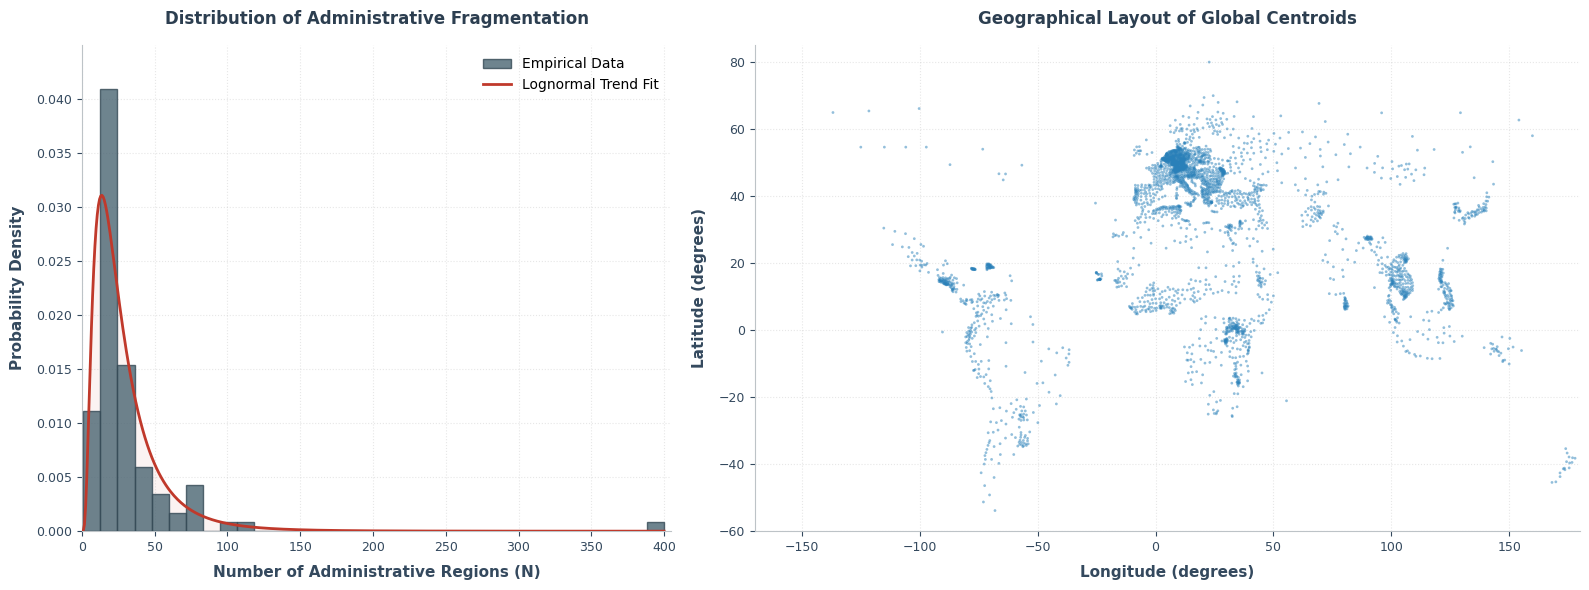

In [7]:
def generate_our_preliminary_plots_perfect_fit():
    nodes_path = GLOBAL_DIR / "nodes.csv"
    if not nodes_path.exists():
        raise FileNotFoundError(f"File not found: {nodes_path}")
        
    df_n = pd.read_csv(nodes_path)

    def label_to_country(label):
        lbl = str(label).strip().upper()
        if ":" in lbl:
            return lbl.split(":")[0]
        if "." in lbl:
            return lbl.split(".")[0]
        return lbl[:3]

    df_n["derived_country"] = df_n["nodeLabel"].map(label_to_country)
    regions_per_country = df_n.groupby("derived_country")["nodeID"].nunique().to_numpy()

    fig, (ax_hist, ax_map) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.4]})

    custom_bins = np.linspace(regions_per_country.min(), regions_per_country.max(), 35)
    
    counts, bins, patches = ax_hist.hist(regions_per_country, bins=custom_bins, color="#4a6572", 
                                         edgecolor="#344955", alpha=0.8, density=True, label="Empirical Data", zorder=3)
    
    shape, loc, scale = stats.lognorm.fit(regions_per_country, floc=0)
    x_fit = np.linspace(regions_per_country.min(), regions_per_country.max(), 500)
    y_fit = stats.lognorm.pdf(x_fit, shape, loc, scale)
    
    ax_hist.plot(x_fit, y_fit, color="#c0392b", lw=2, label="Lognormal Trend Fit", zorder=4)
    ax_hist.fill_between(x_fit, 0, y_fit, color="#c0392b", alpha=0.06, zorder=2)

    ax_hist.set_xlabel("Number of Administrative Regions (N)", fontsize=11, labelpad=8, fontweight="bold", color="#34495e")
    ax_hist.set_ylabel("Probability Density", fontsize=11, labelpad=8, fontweight="bold", color="#34495e")
    ax_hist.set_title("Distribution of Administrative Fragmentation", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")

    ax_hist.grid(True, which="both", ls=":", alpha=0.3, zorder=0)
    ax_hist.legend(frameon=False, loc="upper right", fontsize=10)
    
    ax_hist.set_xlim(0, regions_per_country.max() + 5)
    ax_hist.set_ylim(0, counts.max() * 1.1)

    df_geo_nodes = df_n.dropna(subset=["latitude", "longitude"])
    
    ax_map.scatter(df_geo_nodes["longitude"], df_geo_nodes["latitude"], 
                   s=4, color="#2980b9", alpha=0.5, edgecolors="none", zorder=3)
    
    ax_map.set_xlabel("Longitude (degrees)", fontsize=11, labelpad=8, fontweight="bold", color="#34495e")
    ax_map.set_ylabel("Latitude (degrees)", fontsize=11, labelpad=8, fontweight="bold", color="#34495e")
    ax_map.set_title("Geographical Layout of Global Centroids", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")

    ax_map.grid(True, which="both", ls=":", alpha=0.3, zorder=1)

    ax_map.set_xlim(-170, 180)
    ax_map.set_ylim(-60, 85)

    for ax in [ax_hist, ax_map]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#bdc3c7")
        ax.spines["bottom"].set_color("#bdc3c7")
        ax.tick_params(colors="#34495e", labelsize=9)
    
    plt.tight_layout()
    
    output_path = FIG_DIR / "1_preliminary_characterization.png"
    plt.savefig(output_path, dpi=250)
    print(f"Figura integrata e proporzionata salvata in: {output_path}")
    plt.show()

generate_our_preliminary_plots_perfect_fit()

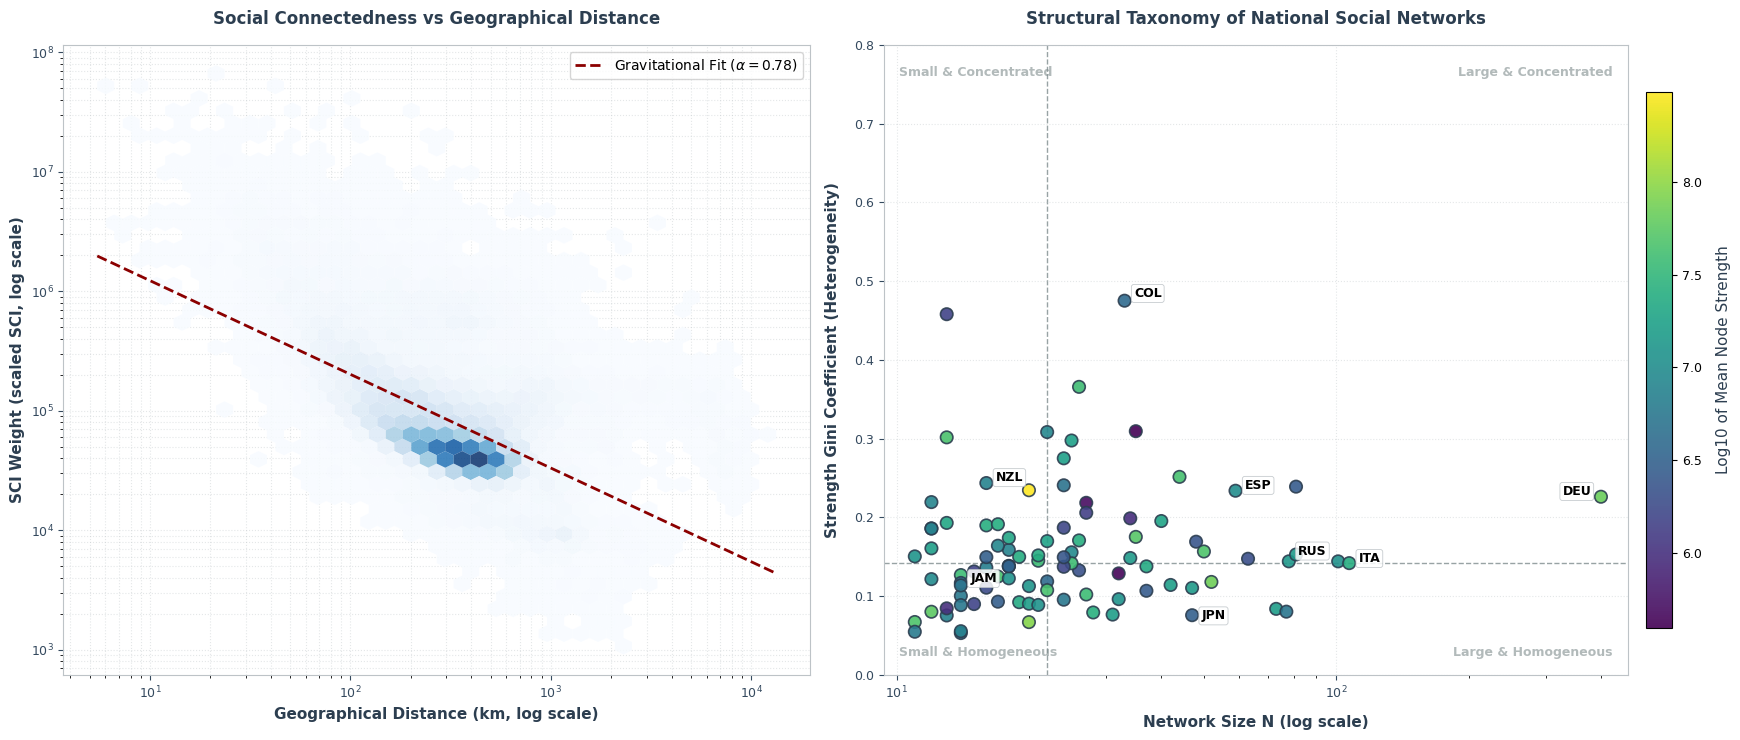

In [9]:
def generate_our_original_analysis_plots():
    ew_path = GLOBAL_DIR / "edges_weighted.csv"
    nodes_path = GLOBAL_DIR / "nodes.csv"

    df_w = pd.read_csv(ew_path)
    df_n = pd.read_csv(nodes_path).set_index("nodeID")
    
    def haversine_np(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        km = 6367 * c
        return km

    df_w = df_w.join(df_n[["latitude", "longitude"]].rename(columns={"latitude": "lat_from", "longitude": "lon_from"}), on="nodeID_from")
    df_w = df_w.join(df_n[["latitude", "longitude"]].rename(columns={"latitude": "lat_to", "longitude": "lon_to"}), on="nodeID_to")
    df_w = df_w.dropna(subset=["lat_from", "lon_from", "lat_to", "lon_to"]).copy()
    df_w["distance_km"] = haversine_np(df_w["lon_from"], df_w["lat_from"], df_w["lon_to"], df_w["lat_to"])

    def _gini_calc(x):
        x = np.sort(x)
        n = len(x)
        if n == 0 or x.sum() == 0: return np.nan
        idx = np.arange(1, n + 1)
        return float((2 * np.sum(idx * x) - (n + 1) * np.sum(x)) / (n * np.sum(x)))

    grp = df_w.groupby("country_ISO3")
    country_rows = []
    for iso3, sub in grp:
        w = sub["scaled_sci"].to_numpy(dtype=float)
        nodes_in_sub = set(sub["nodeID_from"]) | set(sub["nodeID_to"])
        N = len(nodes_in_sub)
        if N >= 10:
            strength = {}
            for f, t, weight in zip(sub["nodeID_from"], sub["nodeID_to"], w):
                strength[f] = strength.get(f, 0.0) + weight
                strength[t] = strength.get(t, 0.0) + weight
            s_vals = np.array(list(strength.values()))
            
            if len(s_vals) > 0:
                country_rows.append({
                    "country": iso3,
                    "N": N,
                    "gini": _gini_calc(s_vals),
                    "mean_strength": s_vals.mean()
                })
                
    df_quadrants = pd.DataFrame(country_rows)

    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={'width_ratios': [1, 1.2]})

    df_geo = df_w[(df_w["distance_km"] > 0) & (df_w["scaled_sci"] > 0)]
    if len(df_geo) > 50000:
        df_geo_sample = df_geo.sample(50000, random_state=42)
    else:
        df_geo_sample = df_geo
        
    ax1.hexbin(df_geo_sample["distance_km"], df_geo_sample["scaled_sci"], xscale="log", yscale="log", 
               gridsize=40, cmap="Blues", mincnt=1, edgecolors="none", alpha=0.85, zorder=2)

    log_x = np.log10(df_geo_sample["distance_km"])
    log_y = np.log10(df_geo_sample["scaled_sci"])
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    x_fit = np.logspace(np.log10(df_geo_sample["distance_km"].min()), np.log10(df_geo_sample["distance_km"].max()), 100)
    y_fit = 10**intercept * (x_fit**slope)
    ax1.loglog(x_fit, y_fit, color="darkred", lw=2, linestyle="--", zorder=4,
               label=fr"Gravitational Fit ($\alpha = {abs(slope):.2f}$)")
    
    ax1.set_xlabel("Geographical Distance (km, log scale)", fontsize=11, fontweight="bold", color="#2c3e50")
    ax1.set_ylabel("SCI Weight (scaled SCI, log scale)", fontsize=11, fontweight="bold", color="#2c3e50")
    ax1.set_title("Social Connectedness vs Geographical Distance", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")
    ax1.grid(True, which="both", ls=":", alpha=0.4, color="#bdc3c7")
    ax1.legend(frameon=True, loc="upper right", fontsize=10)

    med_N = df_quadrants["N"].median()
    med_gini = df_quadrants["gini"].median()

    sc3 = ax3.scatter(df_quadrants["N"], df_quadrants["gini"], 
                      s=80, c=np.log10(df_quadrants["mean_strength"]), 
                      cmap="viridis", edgecolors="#2c3e50", linewidths=1.2, alpha=0.9, zorder=3)

    ax3.axvline(med_N, color="#7f8c8d", linestyle="--", lw=1, alpha=0.8, zorder=1)
    ax3.axhline(med_gini, color="#7f8c8d", linestyle="--", lw=1, alpha=0.8, zorder=1)
    
    ax3.set_xscale("log")
    ax3.set_xlabel("Network Size N (log scale)", fontsize=11, labelpad=10, fontweight="bold", color="#2c3e50")
    ax3.set_ylabel("Strength Gini Coefficient (Heterogeneity)", fontsize=11, labelpad=10, fontweight="bold", color="#2c3e50")
    ax3.set_title("Structural Taxonomy of National Social Networks", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")
    
    ax3.set_ylim(0, 0.8)
    ax3.set_xlim(df_quadrants["N"].min() * 0.85, df_quadrants["N"].max() * 1.15)

    ax3.text(0.02, 0.95, "Small & Concentrated", transform=ax3.transAxes,
             fontsize=9, color="#7f8c8d", fontweight="bold", alpha=0.6, ha="left")
    ax3.text(0.98, 0.95, "Large & Concentrated", transform=ax3.transAxes,
             fontsize=9, color="#7f8c8d", fontweight="bold", alpha=0.6, ha="right")
    ax3.text(0.02, 0.03, "Small & Homogeneous", transform=ax3.transAxes,
             fontsize=9, color="#7f8c8d", fontweight="bold", alpha=0.6, ha="left")
    ax3.text(0.98, 0.03, "Large & Homogeneous", transform=ax3.transAxes,
             fontsize=9, color="#7f8c8d", fontweight="bold", alpha=0.6, ha="right")

    target_countries = ["ITA", "DEU", "ESP", "UK", "JPN", "RUS", "NZL", "JAM", "COL"]
    for _, r in df_quadrants.iterrows():
        if r["country"] in target_countries:
            offset_x = 1.05
            offset_y = 1.01
            ha_param = "left"
            
            if r["country"] == "RUS": offset_y = 1.06
            if r["country"] == "JPN": offset_y = 0.93
            if r["country"] == "JAM": offset_y = 0.93 
            if r["country"] == "DEU": 
                offset_x = 0.95   
                ha_param = "right" 
            
            ax3.text(r["N"] * offset_x, r["gini"] * offset_y, r["country"], 
                     fontsize=9, fontweight="bold", zorder=5, ha=ha_param,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#bdc3c7", lw=0.6, alpha=0.85))

    cb3 = fig.colorbar(sc3, ax=ax3, pad=0.02, shrink=0.85)
    cb3.set_label("Log10 of Mean Node Strength", fontsize=11, labelpad=10, color="#2c3e50")
    cb3.ax.tick_params(labelsize=9)
    ax3.grid(True, which="major", ls=":", alpha=0.4, color="#bdc3c7", zorder=0)

    for ax in [ax1, ax3]:
        ax.spines["top"].set_color("#bdc3c7")
        ax.spines["right"].set_color("#bdc3c7")
        ax.spines["left"].set_color("#bdc3c7")
        ax.spines["bottom"].set_color("#bdc3c7")
        ax.tick_params(colors="#34495e", labelsize=9)

    plt.tight_layout()
    output_path = FIG_DIR / "combined_analysis_and_taxonomy.png"
    plt.savefig(output_path, dpi=250)
    plt.show()

generate_our_original_analysis_plots()

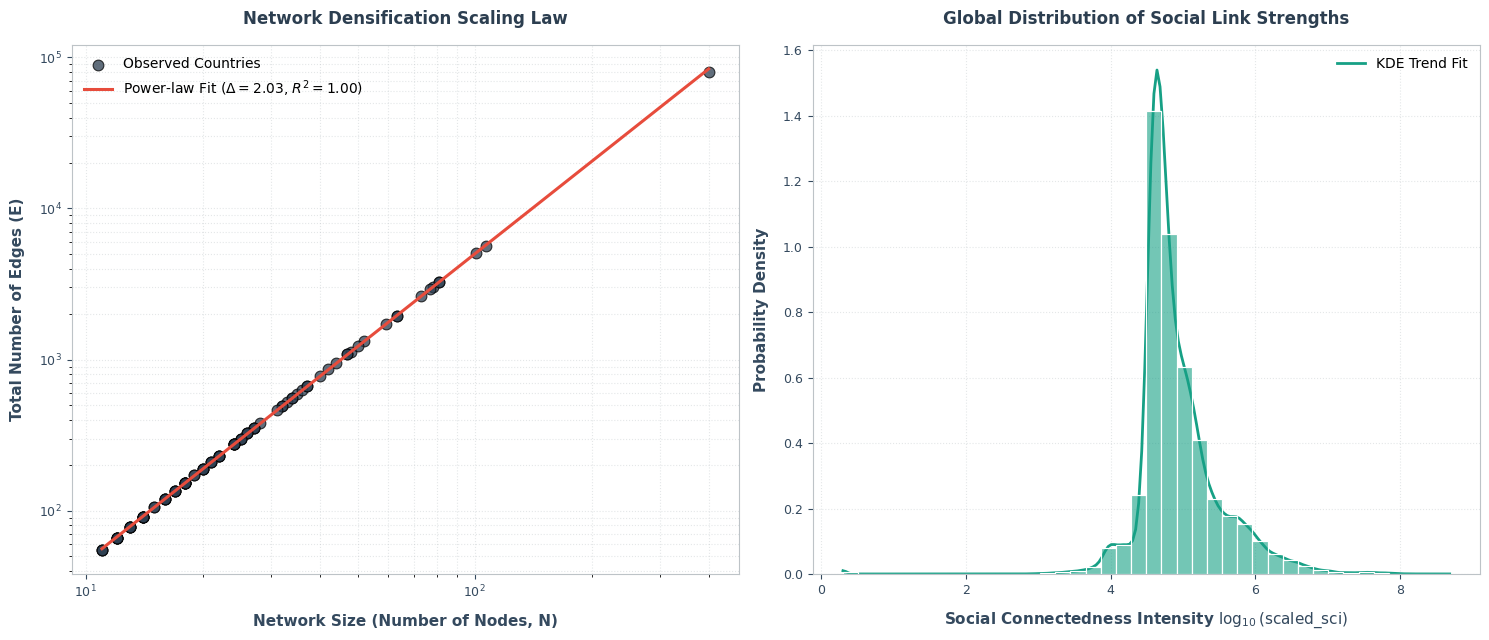

In [10]:
def generate_and_save_perfect_plots():

    nodes_path = GLOBAL_DIR / "nodes.csv"
    edges_path = GLOBAL_DIR / "edges_weighted.csv"
    
    if not nodes_path.exists() or not edges_path.exists():
        raise FileNotFoundError("Assicurati che 'nodes.csv' e 'edges_weighted.csv' siano nella cartella global.")
        
    df_nodes = pd.read_csv(nodes_path)
    df_edges = pd.read_csv(edges_path)

    def id_to_country(node_id):
        lbl = str(node_id).strip().upper()
        if ":" in lbl: return lbl.split(":")[0]
        if "." in lbl: return lbl.split(".")[0]
        return lbl[:3]

    df_nodes["country_ISO3"] = df_nodes["nodeLabel"].map(id_to_country)

    df_n_counts = df_nodes.groupby("country_ISO3")["nodeID"].nunique().reset_index(name="N")
    df_n_counts = df_n_counts[df_n_counts["N"] >= 10]
    valid_countries = df_n_counts["country_ISO3"].unique()
    df_edges_filtered = df_edges[df_edges["country_ISO3"].isin(valid_countries)].copy()
    df_edges_counts = df_edges_filtered.groupby("country_ISO3")["nodeID_from"].count().reset_index(name="E")
    df_scaling = pd.merge(df_n_counts, df_edges_counts, on="country_ISO3")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
    
    color_points = "#2c3e50"
    color_fit = "#e74c3c"

    x_data = df_scaling["N"].to_numpy()
    y1_data = df_scaling["E"].to_numpy()
    
    ax1.scatter(x_data, y1_data, s=60, color=color_points, alpha=0.75, 
                edgecolors="k", linewidths=0.8, label="Observed Countries", zorder=3)
    
    slope1, intercept1, r_val1, p_val1, std_err1 = stats.linregress(np.log10(x_data), np.log10(y1_data))
    x_fit1 = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit1 = (10**intercept1) * (x_fit1**slope1)
    
    ax1.plot(x_fit1, y_fit1, color=color_fit, lw=2.2, zorder=4,
             label=fr"Power-law Fit ($\Delta = {slope1:.2f}$, $R^2 = {r_val1**2:.2f}$)")
    
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Network Size (Number of Nodes, N)", fontsize=11, labelpad=10, fontweight="bold", color="#34495e")
    ax1.set_ylabel("Total Number of Edges (E)", fontsize=11, labelpad=10, fontweight="bold", color="#34495e")
    ax1.set_title("Network Densification Scaling Law", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")
    ax1.grid(True, which="both", ls=":", alpha=0.4, color="#bdc3c7")
    ax1.legend(frameon=False, loc="upper left", fontsize=10)

    weights_log = np.log10(df_edges_filtered["scaled_sci"].dropna().to_numpy())

    sns.histplot(weights_log, bins=40, kde=True, ax=ax2, stat="density",
                 color="#16a085", edgecolors="w", alpha=0.6, zorder=3,
                 line_kws={"color": "#e74c3c", "linewidth": 2, "label": "KDE Trend Fit"})
    
    ax2.set_xlabel(r"Social Connectedness Intensity $\log_{10}(\text{scaled\_sci})$", fontsize=11, labelpad=10, fontweight="bold", color="#34495e")
    ax2.set_ylabel("Probability Density", fontsize=11, labelpad=10, fontweight="bold", color="#34495e")
    ax2.set_title("Global Distribution of Social Link Strengths", fontsize=12, fontweight="bold", pad=15, color="#2c3e50")
    ax2.grid(True, which="major", ls=":", alpha=0.4, color="#bdc3c7")
    ax2.legend(frameon=False, loc="upper right", fontsize=10)

    for ax in [ax1, ax2]:
        ax.spines["top"].set_color("#bdc3c7")
        ax.spines["right"].set_color("#bdc3c7")
        ax.spines["left"].set_color("#bdc3c7")
        ax.spines["bottom"].set_color("#bdc3c7")
        ax.tick_params(colors="#34495e", labelsize=9)
        
    plt.tight_layout()
    
    output_path = FIG_DIR / "5_network_general_characterization.png"
    plt.savefig(output_path, dpi=250)
    plt.show()

generate_and_save_perfect_plots()